# Gold: UGC de Criação (`governor_ugc_mentions`)

ADR [0022](../../docs/adr/0022-notebooks-de-diagnostico-medallion-separados-da-narrativa-do-tcc.md)
(issue [#128](https://github.com/Vini0606/Tecnicas-de-Ciencia-de-Dados-em-dados-do-Instagram/issues/128)).
Diagnóstico de `governor_ugc_mentions` -- posts de TERCEIROS que marcam/mencionam o perfil do
governador (nível "Criar" do funil COBRA-RACE, ADR 0020 Ficha 8 / issue #93). Grão de UMA LINHA
POR POST DE UGC, não agregado por governador -- a agregação
(`GovernorUGCAggregator.aggregate_by_governor`) é uma view calculada nesta seção, não persistida
em Delta (ver docstring de `src/features/gold/ugc_mentions_aggregator.py`).

Este notebook faltava desde que a ADR 0022 foi escrita -- `GOLD_UGC_MENTIONS` já existia em
`config/settings.py` quando a ADR fechou a lista de 7 domínios, mas UGC ficou de fora por
descuido, não por decisão consciente (a própria regra da ADR 0022 sobre "toda tabela Gold nova
exige decisão" não foi aplicada a ela mesma).

Notebook estritamente leitura via `DeltaRepository`, mesmo princípio da ADR
[0003](../../docs/adr/0003-desacoplar-modelagem-do-notebook-via-scripts-cli-com-checkpoint.md).

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from config import settings
from src.repositories.delta_repository import DeltaRepository
from src.features.gold.ugc_mentions_aggregator import GovernorUGCAggregator
from src.analysis.medallion_diagnostics import (
    completeness_summary,
    count_duplicate_rows,
    with_governor_metadata,
)

load_dotenv()
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

repo = DeltaRepository(gold_dir=settings.GOLD_DIR, silver_dir=settings.SILVER_DIR)

## 1. Carga + schema

`id`/`shortCode` são `nullable=True` por contrato de schema (piloto do actor não garantia `id`
sempre presente) -- `UGCMentionCleaner` já descarta na Silver qualquer linha sem NENHUM dos dois,
então aqui os dois convivem como candidatos de identificação, nunca ambos nulos ao mesmo tempo.
`governor_username` é derivado (`mentions`/`taggedUsers` cruzados contra a lista de governadores
conhecidos), não um campo bruto do actor -- pode ser nulo quando o post não correlaciona com
nenhum governador do projeto.

In [2]:
df_ugc = repo.load_ugc_mentions()
df_ugc.dtypes

id                                object
shortCode                         object
governor_username                 object
authorUsername                    object
caption                           object
likesCount                         int64
commentsCount                      int64
videoPlayCount                   float64
is_organic                          bool
data_hora                 datetime64[us]
_run_id                           object
_generated_at        datetime64[us, UTC]
dtype: object

## 2. Completude

`governor_username` nulo é uma limitação DECLARADA (ADR 0020, Ficha 8), não um bug de
coleta -- mede quanto do volume de UGC coletado não é atribuível a nenhum governador
monitorado pelo projeto.

In [3]:
completude = completeness_summary(df_ugc)
print(f"linhas duplicadas (por id+shortCode): {count_duplicate_rows(df_ugc, subset=['id', 'shortCode'])}")

n_total = len(df_ugc)
n_sem_governor = int(df_ugc['governor_username'].isna().sum())
pct_sem_governor = (n_sem_governor / n_total * 100) if n_total else 0.0
print(f"{n_sem_governor} de {n_total} posts sem governor_username resolvido ({pct_sem_governor:.1f}%)")

completude[completude['n_nulos'] > 0]

linhas duplicadas (por id+shortCode): 0
1 de 91 posts sem governor_username resolvido (1.1%)


,coluna,dtype,n_nulos,pct_nulos,n_unicos
2,governor_username,object,1,1.0989,20
7,videoPlayCount,float64,53,58.2418,38


## 3. Distribuições univariadas

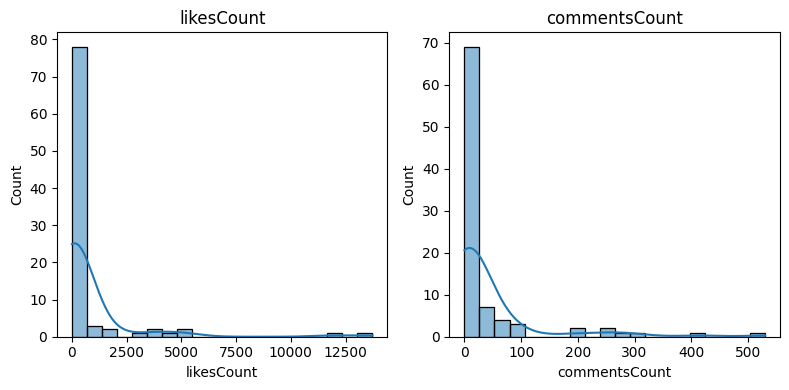

38 de 91 posts são vídeo (videoPlayCount não-nulo)


count      38.0000
mean     6317.1842
std     13644.5760
min         0.0000
25%       467.7500
50%      1147.0000
75%      3949.0000
max     71613.0000
Name: videoPlayCount, dtype: float64

is_organic
True    91
Name: count, dtype: int64


In [4]:
metricas_chave = ['likesCount', 'commentsCount']
fig, axes = plt.subplots(1, len(metricas_chave), figsize=(4 * len(metricas_chave), 4))
for ax, coluna in zip(axes, metricas_chave):
    sns.histplot(df_ugc[coluna], kde=True, ax=ax)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

n_com_video = int(df_ugc['videoPlayCount'].notna().sum())
print(f"{n_com_video} de {n_total} posts são vídeo (videoPlayCount não-nulo)")
if n_com_video:
    display(df_ugc['videoPlayCount'].describe())

print(df_ugc['is_organic'].value_counts(dropna=False))

## 4. Evolução temporal

Sem tabela `_history` irmã para `governor_ugc_mentions` hoje (`DeltaRepository` não expõe
nenhum `load_ugc_mentions_history`) -- seção do esqueleto padrão pulada de propósito, mesmo
caso já documentado em `gold_nsm.ipynb`.

## 5. Relação com covariáveis (partido/UF) e orgânico vs. pago

`governor_ugc_mentions` não tem `inputUrl` (só `governor_username`) -- o join com
`governors_metadata` (que espera `inputUrl`) passa primeiro por `governor_engagement`
(`username` + `inputUrl`), não por um segundo jeito de acessar Delta.

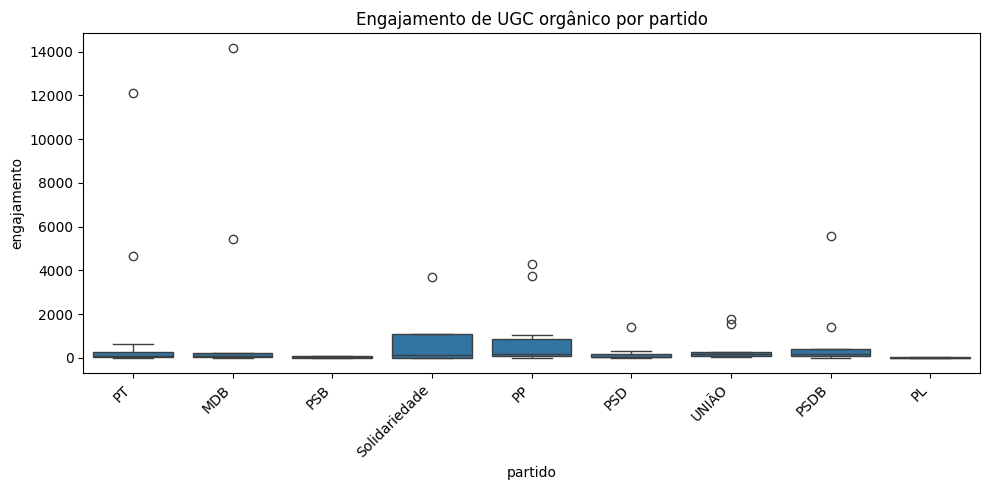

In [5]:
df_username_para_input = repo.load_profiles()[['username', 'inputUrl']]
df_ugc_com_input = df_ugc.merge(
    df_username_para_input, left_on='governor_username', right_on='username', how='left'
)
df_com_metadado = with_governor_metadata(df_ugc_com_input, repo.load_governors_metadata())

df_organico = df_com_metadado[df_com_metadado['is_organic']].copy()
df_organico['engajamento'] = df_organico['likesCount'].fillna(0) + df_organico['commentsCount'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_organico, x='partido', y='engajamento', ax=ax)
ax.set_title('Engajamento de UGC orgânico por partido')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
df_agregado_por_governador = GovernorUGCAggregator().aggregate_by_governor(df_ugc)
df_agregado_por_governador.sort_values('pct_organic')

,governor_username,count_organic,count_paid,avg_engagement_organic,pct_organic
0,antoniodenariumrr,5,0,67.8000,1.0000
1,carlosbrandaoma,5,0,58.8000,1.0000
2,clecioluis_,4,0,977.5000,1.0000
3,eduardoleite,5,0,245.2000,1.0000
4,eduardoriedel,5,0,73.6000,1.0000
5,elmanofreitas,4,0,3256.7500,1.0000
6,fabiogov55,5,0,90.2000,1.0000
7,fatimabezerra13,5,0,126.8000,1.0000
8,gladsoncameli,5,0,1907.4000,1.0000
9,helderbarbalho,5,0,2879.2000,1.0000


## 6. Outliers

Engajamento extremo de UGC orgânico (>3 desvios-padrão acima da média) sinalizado à parte --
publi (`is_organic == False`) já foi excluída antes deste corte, então um outlier aqui é
necessariamente apoio espontâneo de alto engajamento, não publi disfarçada.

In [7]:
df_ugc_organico = df_ugc[df_ugc['is_organic']].copy()
df_ugc_organico['engajamento'] = (
    df_ugc_organico['likesCount'].fillna(0) + df_ugc_organico['commentsCount'].fillna(0)
)
media = df_ugc_organico['engajamento'].mean()
desvio = df_ugc_organico['engajamento'].std()
limite = media + 3 * desvio

outliers = df_ugc_organico[df_ugc_organico['engajamento'] > limite]
print(f"{len(outliers)} posts de UGC orgânico com engajamento > {limite:.0f} (média + 3 desvios)")
outliers[
    ['governor_username', 'authorUsername', 'likesCount', 'commentsCount', 'data_hora']
].sort_values('likesCount', ascending=False)

2 posts de UGC orgânico com engajamento > 7355 (média + 3 desvios)


,governor_username,authorUsername,likesCount,commentsCount,data_hora
8,helderbarbalho,danibarbalho,13732,415,2022-12-25 00:36:10
2,elmanofreitas,elmanofreitas,11838,282,2022-09-30 21:06:50


## Nota de interpretação

Dois cuidados antes de usar esta tabela para qualquer ranking editorial: (1) volume de UGC não
é normalizado por tamanho de audiência -- governadores com mais seguidores tendem a acumular mais
menções só por isso, limitação já declarada em `GovernorUGCAggregator.aggregate_by_governor`;
(2) `governor_username` nulo (posts não correlacionáveis) não deve ser contado como "zero UGC"
para nenhum governador -- é ausência de correlação, não ausência de menção real.